In [1]:
import requests
import pandas as pd

In [2]:
def get_history(coin, days):

    url = f"https://api.coingecko.com/api/v3/coins/{coin}/market_chart"

    params = {
        "vs_currency" : "jpy",
        "days": days
    }

    response = requests.get(url,params=params)

    data = response.json()

    df = pd.DataFrame(
        data["prices"],
        columns=["Timestamp", "Price"]
    )

    df["Date"] = pd.to_datetime(
        df["Timestamp"],
        unit="ms"
    )

    df["Coin"] = coin

    return df.drop(columns="Timestamp")

In [3]:
coins = [
    "bitcoin",
    "ethereum",
    "solana"
]

all_df = []

for coin in coins:

    df = get_history(coin, 365)

    all_df.append(df)

crypto_df = pd.concat(
    all_df,
    ignore_index=True
)


In [4]:
crypto_df

,Price,Date,Coin
0,1.720407e+07,2025-08-10 00:00:00,bitcoin
1,1.767547e+07,2025-08-11 00:00:00,bitcoin
2,1.754568e+07,2025-08-12 00:00:00,bitcoin
3,1.767568e+07,2025-08-13 00:00:00,bitcoin
4,1.823215e+07,2025-08-14 00:00:00,bitcoin
...,...,...,...
1093,1.166418e+04,2026-08-06 00:00:00,solana
1094,1.151253e+04,2026-08-07 00:00:00,solana
1095,1.161281e+04,2026-08-08 00:00:00,solana
1096,1.198684e+04,2026-08-09 00:00:00,solana


前処理

In [5]:
crypto_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1098 entries, 0 to 1097
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Price   1098 non-null   float64       
 1   Date    1098 non-null   datetime64[ns]
 2   Coin    1098 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 25.9+ KB


In [6]:
crypto_df.head()

,Price,Date,Coin
0,1.720407e+07,2025-08-10,bitcoin
1,1.767547e+07,2025-08-11,bitcoin
2,1.754568e+07,2025-08-12,bitcoin
3,1.767568e+07,2025-08-13,bitcoin
4,1.823215e+07,2025-08-14,bitcoin


In [7]:
crypto_df.describe()

,Price,Date
count,1.098000e+03,1098
mean,4.556074e+06,2026-02-08 11:57:07.349726720
min,9.968505e+03,2025-08-10 00:00:00
25%,2.440935e+04,2025-11-09 00:00:00
50%,3.728909e+05,2026-02-08 12:00:00
75%,1.066667e+07,2026-05-11 00:00:00
max,1.896351e+07,2026-08-09 06:26:50
std,6.311062e+06,NaN


In [8]:
crypto_df["Date"] = pd.to_datetime(crypto_df["Date"])
crypto_df["Year"] = crypto_df["Date"].dt.year
crypto_df["Month"] = crypto_df["Date"].dt.month
crypto_df["Weekday"] = crypto_df["Date"].dt.day_name()

crypto_df

,Price,Date,Coin,Year,Month,Weekday
0,1.720407e+07,2025-08-10 00:00:00,bitcoin,2025,8,Sunday
1,1.767547e+07,2025-08-11 00:00:00,bitcoin,2025,8,Monday
2,1.754568e+07,2025-08-12 00:00:00,bitcoin,2025,8,Tuesday
3,1.767568e+07,2025-08-13 00:00:00,bitcoin,2025,8,Wednesday
4,1.823215e+07,2025-08-14 00:00:00,bitcoin,2025,8,Thursday
...,...,...,...,...,...,...
1093,1.166418e+04,2026-08-06 00:00:00,solana,2026,8,Thursday
1094,1.151253e+04,2026-08-07 00:00:00,solana,2026,8,Friday
1095,1.161281e+04,2026-08-08 00:00:00,solana,2026,8,Saturday
1096,1.198684e+04,2026-08-09 00:00:00,solana,2026,8,Sunday


土日と平日で違いはある？

In [9]:
crypto_df["DayType"] = crypto_df["Weekday"].apply(
    lambda x:"Weekend"
    if x in ["Saturday","Sunday"]
    else "Weekday"
)
crypto_df

,Price,Date,Coin,Year,Month,Weekday,DayType
0,1.720407e+07,2025-08-10 00:00:00,bitcoin,2025,8,Sunday,Weekend
1,1.767547e+07,2025-08-11 00:00:00,bitcoin,2025,8,Monday,Weekday
2,1.754568e+07,2025-08-12 00:00:00,bitcoin,2025,8,Tuesday,Weekday
3,1.767568e+07,2025-08-13 00:00:00,bitcoin,2025,8,Wednesday,Weekday
4,1.823215e+07,2025-08-14 00:00:00,bitcoin,2025,8,Thursday,Weekday
...,...,...,...,...,...,...,...
1093,1.166418e+04,2026-08-06 00:00:00,solana,2026,8,Thursday,Weekday
1094,1.151253e+04,2026-08-07 00:00:00,solana,2026,8,Friday,Weekday
1095,1.161281e+04,2026-08-08 00:00:00,solana,2026,8,Saturday,Weekend
1096,1.198684e+04,2026-08-09 00:00:00,solana,2026,8,Sunday,Weekend


In [10]:
result = (
    crypto_df.groupby("DayType")["Price"]
    .mean()
    .round(2)
)

print(result)

DayType
Weekday    4568852.98
Weekend    4524730.86
Name: Price, dtype: float64


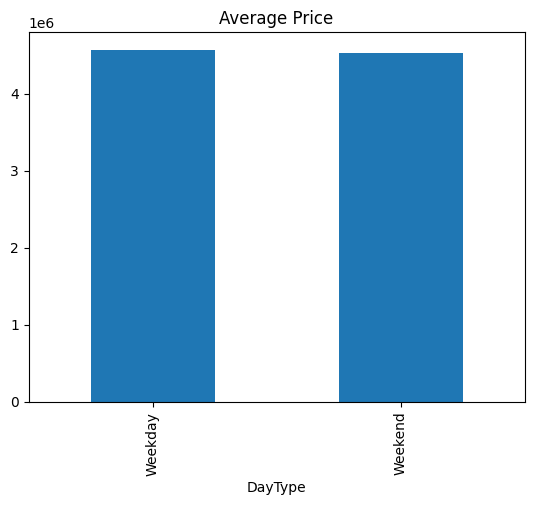

In [11]:
import matplotlib.pyplot as plt

result.plot(kind="bar")
plt.title("Average Price")

plt.show()

大きく下がった日の共通点

In [12]:
crypto_df["Return"] = (
    crypto_df.groupby("Coin")["Price"]
             .pct_change()
             *100
)

In [13]:
big_drop = (
    crypto_df.nsmallest(
        10,
        "Return"
    )
)

print(
    big_drop[
        [
            "Date",
            "Price",
            "Return"
        ]
    ]
)

          Date         Price     Return
546 2026-02-06  2.867031e+05 -14.692598
912 2026-02-06  1.232520e+04 -14.616535
794 2025-10-11  2.854450e+04 -14.555439
180 2026-02-06  9.868767e+06 -13.856195
428 2025-10-11  5.808419e+05 -12.058049
818 2025-11-04  2.546857e+04 -11.995828
666 2026-06-06  2.536762e+05 -10.546611
907 2026-02-01  1.636845e+04  -9.959873
748 2025-08-26  2.760677e+04  -9.307003
541 2026-02-01  3.802492e+05  -9.088447


月ごとの平均価格

In [14]:
monthly = (
    crypto_df.groupby(crypto_df["Date"].dt.month)["Price"]
    .mean()
    .round()
)

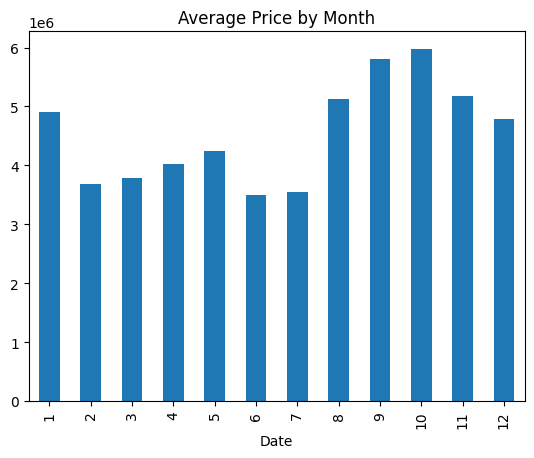

In [15]:
monthly.plot(
    kind="bar"
)

plt.title(
    "Average Price by Month"
)

plt.show()

どの年のボラティリティが大きい？

In [16]:
volatility = (
    crypto_df.groupby("Year")["Return"]
      .std()
      .round(2)
)

print(volatility)

Year
2025    3.39
2026    3.01
Name: Return, dtype: float64


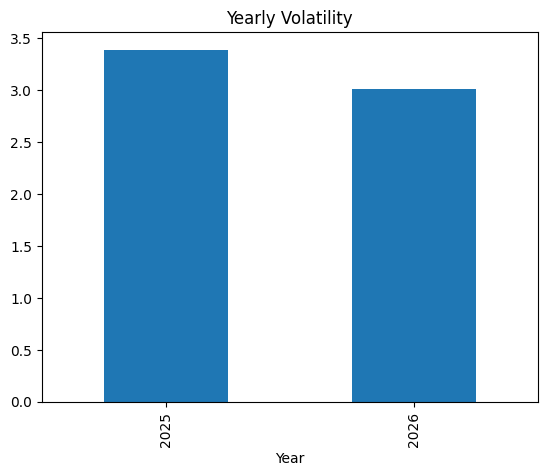

In [17]:
volatility.plot(
    kind="bar"
)

plt.title(
    "Yearly Volatility"
)

plt.show()

銘柄別ボラティリティ

In [18]:
volatility_coin = (
    crypto_df.groupby("Coin")["Return"]
      .std()
      .round(2)
)

print(volatility_coin)

Coin
bitcoin     2.27
ethereum    3.41
solana      3.65
Name: Return, dtype: float64


曜日ごとの平均リターン

In [19]:
big_drop_weekday = (
    crypto_df.groupby("Weekday")["Return"]
      .mean()
      .round(2)
)

print(big_drop_weekday)

Weekday
Friday      -1.31
Monday       0.20
Saturday    -0.11
Sunday      -0.01
Thursday     0.26
Tuesday      0.19
Wednesday   -0.19
Name: Return, dtype: float64


30日移動平均線（MA30）

In [20]:
crypto_df["MA30"] = (
    crypto_df
    .groupby("Coin")["Price"]
    .transform(
        lambda x:
        x.rolling(30).mean()
    )
)

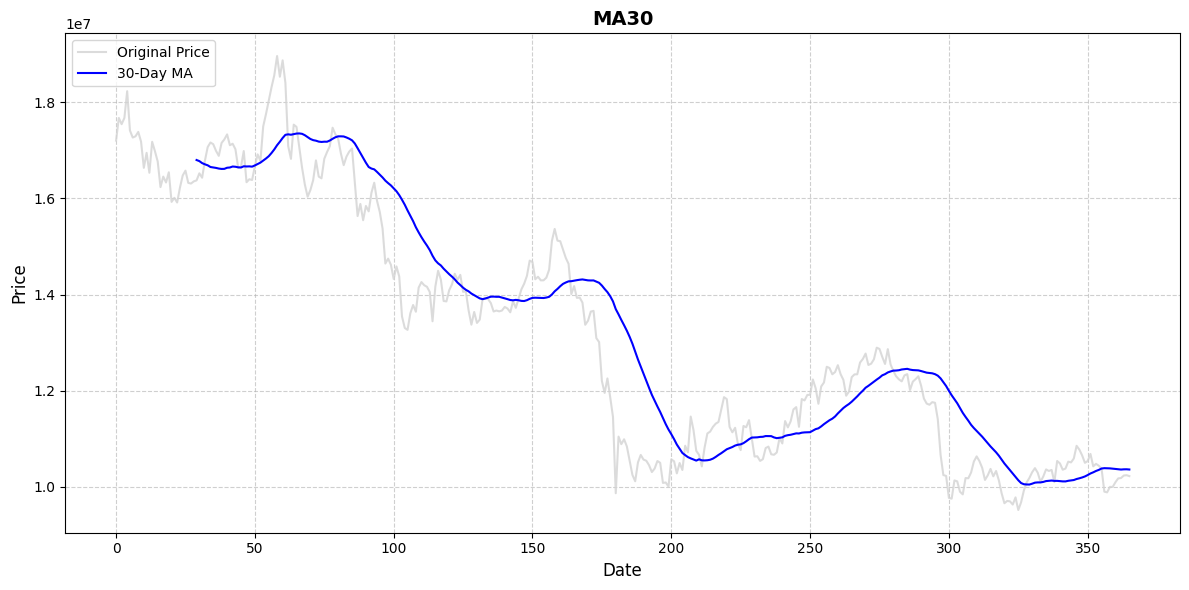

In [21]:
btc = crypto_df[
    crypto_df["Coin"]=="bitcoin"
]

plt.figure(figsize=(12, 6))

plt.plot(btc["Price"], label="Original Price", color="lightgray", alpha=0.8)
plt.plot(btc["MA30"], label="30-Day MA", color="blue", linewidth=1.5)

plt.title("MA30", fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()

前日の価格

In [22]:
crypto_df["Price_Yesterday"] = (
    crypto_df
    .groupby("Coin")["Price"]
    .shift(1)
)

7日移動平均

In [23]:
crypto_df["Volatility7"] = (
    crypto_df
    .groupby("Coin")["Return"]
    .transform(
        lambda x:x.rolling(7).std()
    )
)

前日リターン

In [24]:
crypto_df["Return_Yesterday"] = (
    crypto_df
    .groupby("Coin")["Return"]
    .shift(1)
)

翌日の価格

In [25]:
crypto_df["Target"] = (
    crypto_df
    .groupby("Coin")["Price"]
    .shift(-1)
)

MA7

In [26]:
crypto_df["MA7"] = (
    crypto_df
    .groupby("Coin")["Price"]
    .transform(
        lambda x: x.rolling(7).mean()
    )
)

In [27]:
crypto_df = crypto_df.dropna()
crypto_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1008 entries, 29 to 1096
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Price             1008 non-null   float64       
 1   Date              1008 non-null   datetime64[ns]
 2   Coin              1008 non-null   object        
 3   Year              1008 non-null   int32         
 4   Month             1008 non-null   int32         
 5   Weekday           1008 non-null   object        
 6   DayType           1008 non-null   object        
 7   Return            1008 non-null   float64       
 8   MA30              1008 non-null   float64       
 9   Price_Yesterday   1008 non-null   float64       
 10  Volatility7       1008 non-null   float64       
 11  Return_Yesterday  1008 non-null   float64       
 12  Target            1008 non-null   float64       
 13  MA7               1008 non-null   float64       
dtypes: datetime64[ns](1), float6

Bitcoinだけ取り出す

In [28]:
btc_df = crypto_df[
    crypto_df["Coin"] == "bitcoin"
].copy()

xとyを作る

In [29]:
features = [
    "Price",
    "Price_Yesterday",
    "MA7",
    "MA30",
    "Volatility7",
    "Return_Yesterday"
]

x = btc_df[features]

y = btc_df["Target"]

80% Training / 20% Test に時系列順で分割する

In [30]:
split = int(len(btc_df) * 0.8)

x_train = x.iloc[:split]
x_test  = x.iloc[split:]

y_train = y.iloc[:split]
y_test  = y.iloc[split:]

In [31]:
print("x_train:", x_train.shape)
print("x_test :", x_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

x_train: (268, 6)
x_test : (68, 6)
y_train: (268,)
y_test : (68,)


Linear Regression

In [32]:
from sklearn.linear_model import LinearRegression

In [33]:
lr_model = LinearRegression()

In [34]:
lr_model.fit(
    x_train,
    y_train
)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [35]:
lr_prediction = lr_model.predict(
    x_test
)

Random Forest

In [36]:
from sklearn.ensemble import RandomForestRegressor

In [37]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [38]:
rf_model.fit(
    x_train,
    y_train
)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [39]:
rf_prediction = rf_model.predict(
    x_test
)

評価指標をimport

In [40]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

Linear Regression：

In [41]:
lr_mae = mean_absolute_error(
    y_test,
    lr_prediction      
)

lr_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        lr_prediction
    )
)

lr_r2 = r2_score(
    y_test,
    lr_prediction
)

Random Forest：

In [42]:
rf_mae = mean_absolute_error(
    y_test,
    rf_prediction
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_prediction
    )
)

rf_r2 = r2_score(
    y_test,
    rf_prediction
)

In [43]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        lr_mae,
        rf_mae
    ],
    "RMSE": [
        lr_rmse,
        rf_rmse
    ],
    "R2": [
        lr_r2,
        rf_r2
    ]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,136702.027775,179737.298663,0.633473
1,Random Forest,338316.298528,411941.061673,-0.925306


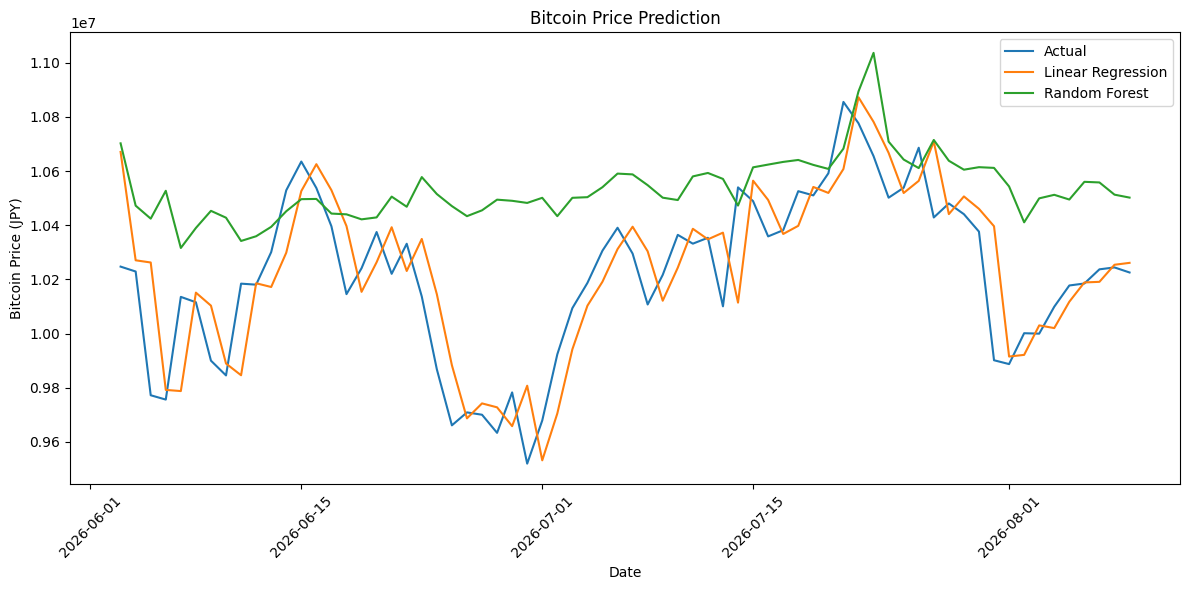

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    btc_df["Date"].iloc[split:],
    y_test,
    label="Actual"
)

plt.plot(
    btc_df["Date"].iloc[split:],
    lr_prediction,
    label="Linear Regression"
)

plt.plot(
    btc_df["Date"].iloc[split:],
    rf_prediction,
    label="Random Forest"
)

plt.xlabel("Date")
plt.ylabel("Bitcoin Price (JPY)")
plt.title(
    "Bitcoin Price Prediction"
)

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()